In [13]:
from PIL import Image
import numpy as np
imgpil=Image.open("Photos/lO3vSCog.png")
img=np.array(imgpil)

In [14]:
print(img.shape)

(1365, 2048, 3)


In [15]:
img[200,100]=(125,30,255)

In [28]:
def filtre_rouge(img_orig):
    im=np.copy(img_orig)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            r,v,b=im[i,j]
            im[i,j]=(r,0,0)
    return im

def filtre_bleu(img_orig):
    im=np.copy(img_orig)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            r,v,b=im[i,j]
            im[i,j]=(0,0,b)
    return im

def filtre_vert(img_orig):
    im=np.copy(img_orig)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            r,v,b=im[i,j]
            im[i,j]=(0,v,0)
    return im

imgpil=Image.fromarray(filtre_rouge(img))
imgpil.save("resultat_rouge.png")
imgpil=Image.fromarray(filtre_bleu(img))
imgpil.save("resultat_bleu.png")
imgpil=Image.fromarray(filtre_vert(img))
imgpil.save("resultat_vert.png")

resultat_rouge.png


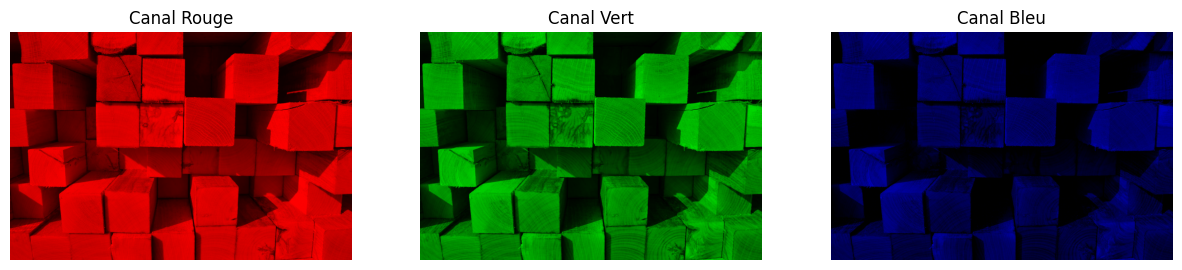

In [30]:
import matplotlib.pyplot as plt

# Génération des images filtrées
img_r = filtre_rouge(img)
img_v = filtre_vert(img)
img_b = filtre_bleu(img)

# Création d'une figure avec 1 ligne et 3 colonnes
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Affichage de chaque version
axs[0].imshow(img_r)
axs[0].set_title("Canal Rouge")
axs[0].axis('off') # Cache les axes gradués

axs[1].imshow(img_v)
axs[1].set_title("Canal Vert")
axs[1].axis('off')

axs[2].imshow(img_b)
axs[2].set_title("Canal Bleu")
axs[2].axis('off')

plt.show()

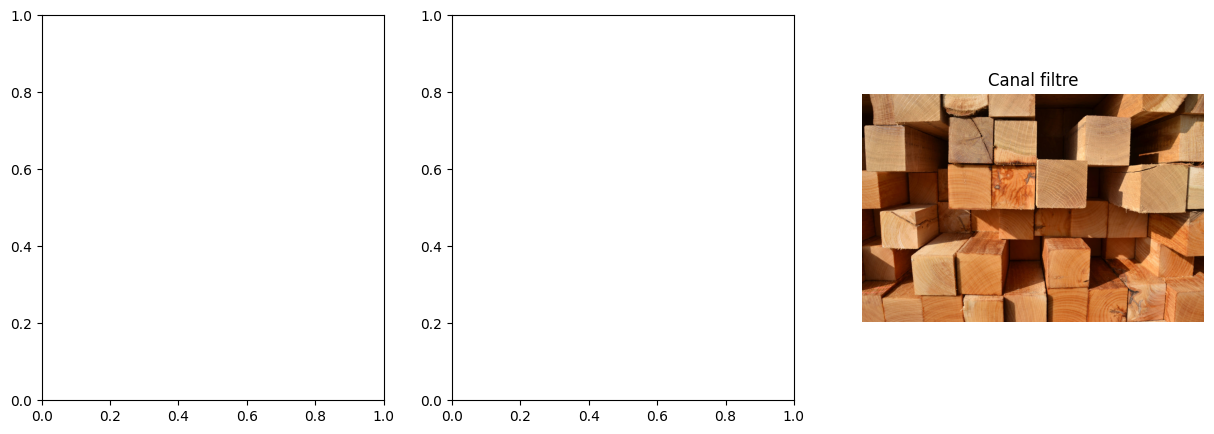

In [38]:
def filtre(img_orig):
    im=np.copy(img_orig)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            r,v,b=im[i,j]
            im[i,j]=(r,0,b)
    return im
imgpil=Image.fromarray(filtre(img))
imgpil.save("resultat_filtre.png")
img_d = (img)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[2].imshow(img_d)
axs[2].set_title("Canal filtre")
axs[2].axis('off')
plt.show()

In [ ]:
from math import exp, pi
def gaussKernel(r,sigma):
    kernel = [[0] * (2*r+1) for _ in range(2*r + 1)]
    if sigma > 0:
        gaussianKernelFactor, e = 0, 0
        for ky in range(-r,r):
            for kx in range(-r,r):
                e = exp(-(kx**2+ky**2)/(2*pi*sigma**2))
                gaussianKernelFactor += e
                kernel[kx+r][ky+r] = e
        
        for ky in range(-r,r):
            for kx in range(-r,r):
                kernel[kx+r][ky+r] = kernel[kx+r][ky+r] / gaussianKernelFactor
                
    return kernel
                
def convolution(img,M):
    px = int( (len(M)-1) / 2 )
    im = img.copy()
    imax = img.shape[1] - px
    for i in range(px,imax):
        for j in range(px,img.shape[0]-px):
            somme = 0.0
            for k in range(-px,px+1):
                for l in range(-px,px+1):
                    somme += img[j+l][i+k] * M[l+px][k+px]
            im[j][i] = somme
    return im

imgpil=Image.open("Photos/lO3vSCog.png")
img = np.array(imgpil) 
H = gaussKernel(10,30)
imgpil = Image.fromarray(convolution(img,H))
imgpil.save("resultat_flou.jpg")

In [55]:
from PIL import Image 
from PIL import ImageFilter
from PIL.ImageFilter import (GaussianBlur)
simg = Image.open("Photos/lO3vSCog.png")
# defaut: radius=2
dimg = simg.filter(GaussianBlur(radius=10))
dimg.save("image_floue.jpg")



In [58]:
from scipy import ndimage



In [63]:
from scipy import ndimage
import numpy as np
from PIL import Image

# 1. Charger l'image
monalisa_pil = Image.open("Photos/monalisa.png")
monalisa_np = np.array(monalisa_pil)

# 2. Appliquer le filtre médian
# (3, 3, 1) signifie : fenêtre de 3x3 sur l'espace, mais on ne mélange pas les 3 canaux RGB
img_debruitee = ndimage.median_filter(monalisa_np, size=(3, 3, 1))

# 3. Reconvertir pour afficher
resultat = Image.fromarray(img_debruitee)
resultat.show()

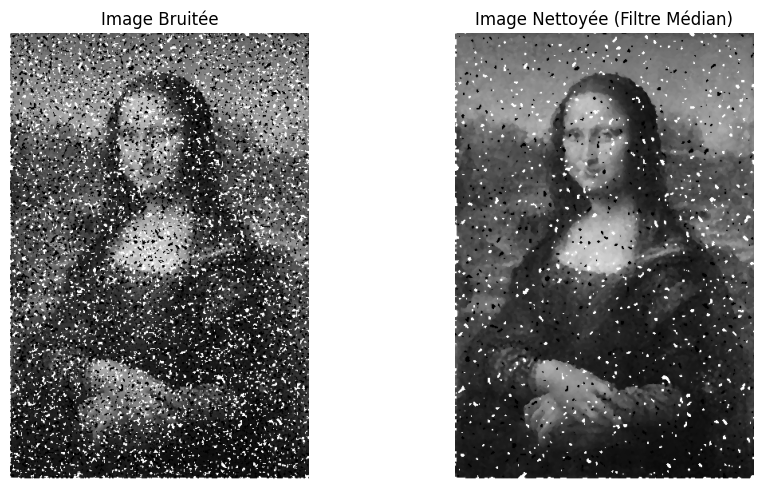

In [71]:
from PIL import Image
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

# 1. Charger votre image bruitée
try:
    imgpil = Image.open("Photos/monalisa.png")
    # L'image semble être en niveaux de gris (un seul canal)
    # Assurons-nous d'avoir un tableau NumPy correct (L = Luminance)
    img_np = np.array(imgpil.convert('L')) 
except FileNotFoundError:
    print("Fichier introuvable. Assurez-vous d'avoir téléchargé image_0.png.")
    exit()

# 2. Appliquer le filtre Médian
# La taille (size=3) correspond à une fenêtre de 3x3 pixels pour chaque calcul.
# C'est généralement suffisant pour éliminer ce type de bruit.
img_nettoyee = ndimage.median_filter(img_np, size=4)

# 3. Affichage Comparatif
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_np, cmap='gray')
plt.title("Image Bruitée")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_nettoyee, cmap='gray')
plt.title("Image Nettoyée (Filtre Médian)")
plt.axis('off')

plt.tight_layout()
plt.show()

# 4. Sauvegarder le résultat
final = Image.fromarray(img_nettoyee)
final.save("monalisa_restoree.png")

In [79]:
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage import img_as_float

# Convertir l'image en flottants pour le débruitage
img_float = img_as_float(img_np)

# Estimer le niveau de bruit pour régler le filtre
sigma_est = np.mean(estimate_sigma(img_float, multichannel=False))

# Appliquer le débruitage Non-Local Means
img_nettoyee_nlm = denoise_nl_means(img_float, h=1.15 * sigma_est, fast_mode=True,
                                    patch_size=5, patch_distance=6, multichannel=False)

# Reconvertir en uint8
img_nettoyee_nlm = (img_nettoyee_nlm * 255).astype(np.uint8)

TypeError: estimate_sigma() got an unexpected keyword argument 'multichannel'

In [82]:
import cv2
import matplotlib.pyplot as plt

print(cv2.__version__)


4.13.0


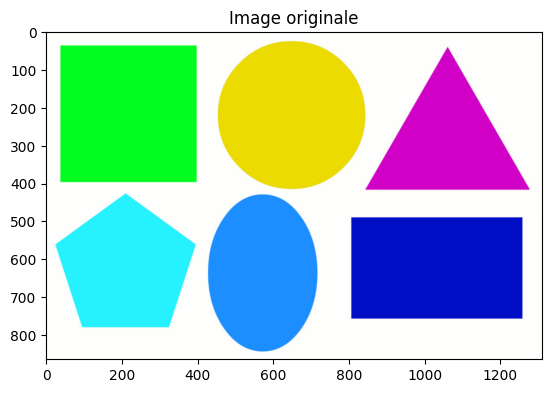

In [87]:


import cv2
import matplotlib.pyplot as plt

# Charger une image
image = cv2.imread("Photos/mX22pSyA.png")

# Afficher l'image
plt.imshow(image)
plt.title('Image originale')
plt.show()

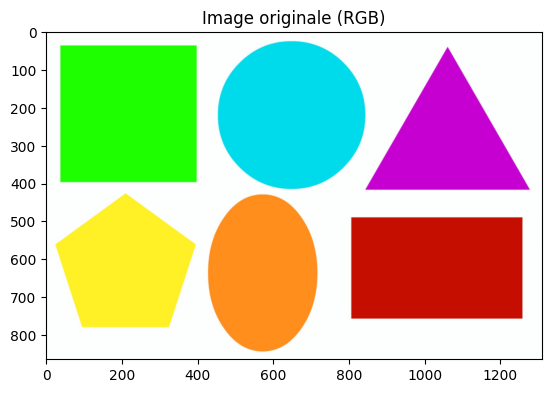

In [91]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

#afficher l'image

plt.imshow(image_rgb)
plt.title('Image originale (RGB)')
plt.show()


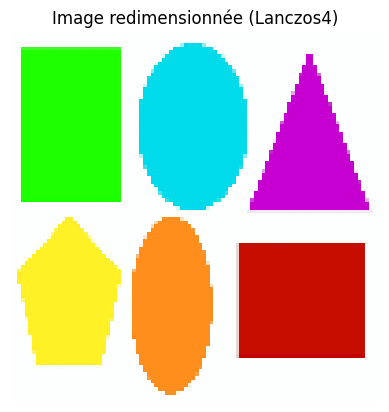

In [99]:
import cv2
import matplotlib.pyplot as plt

# 1. Charger l'image
image = cv2.imread("Photos/mX22pSyA.png")

# OpenCV charge en BGR, Matplotlib affiche en RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. Redimensionner correctement
# Syntaxe : cv2.resize(src, dsize, interpolation)
resized_image = cv2.resize(image_rgb, (100, 100), interpolation=cv2.INTER_LANCZOS4)

# 3. Afficher
plt.imshow(resized_image)
plt.title('Image redimensionnée (Lanczos4)')
plt.axis('off')
plt.show()

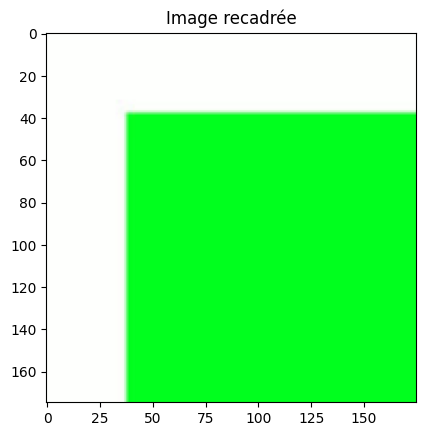

In [172]:
import cv2
import matplotlib.pyplot as plt

# Charger une image
image = cv2.imread("Photos/mX22pSyA.png")

# Recadrer l'image
cropped_image = image[0:175, 0:175]

# Afficher l'image recadrée
plt.imshow(cropped_image)
plt.title('Image recadrée')
plt.show()

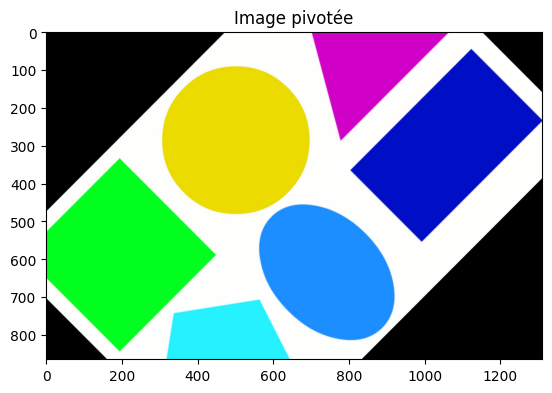

In [103]:
# Définir le centre de rotation
center = (image.shape[1] // 2, image.shape[0] // 2)

# Créer la matrice de rotation
matrix = cv2.getRotationMatrix2D(center, 45, 1.0)

# Faire pivoter l'image
rotated_image = cv2.warpAffine(image, matrix, (image.shape[1], image.shape[0]))

# Afficher l'image pivotée
plt.imshow(rotated_image)
plt.title('Image pivotée')
plt.show()

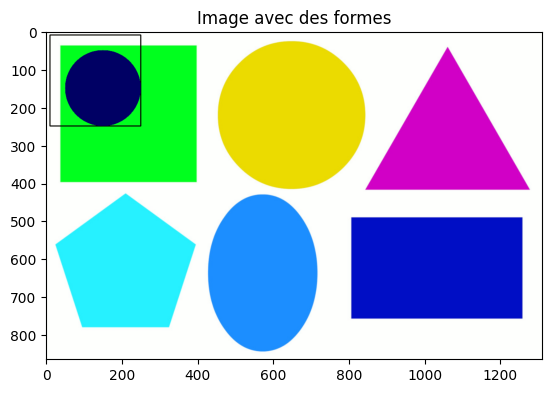

In [169]:
image = cv2.imread("Photos/mX22pSyA.png")

# Dessiner un rectangle
cv2.rectangle(image, (10, 10), (250, 250), (5, 5, 0), 2)

# Dessiner un cercle
cv2.circle(image, (150, 150), 100, (0, 0, 100), -1)

# Afficher l'image avec des formes
plt.imshow(image)
plt.title('Image avec des formes')
plt.show()

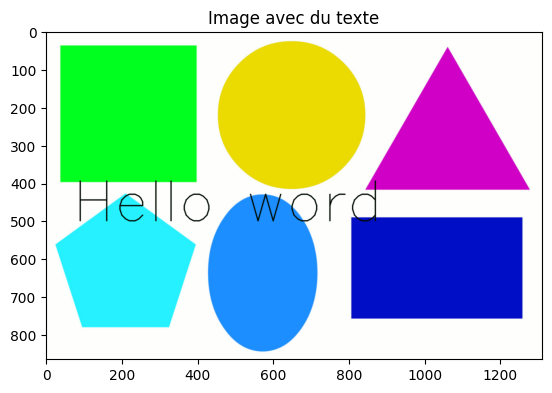

In [144]:
 #Définir la police
image = cv2.imread("Photos/mX22pSyA.png")

font = cv2.FONT_HERSHEY_SIMPLEX

# Ajouter du texte à l'image
cv2.putText(image, 'Hello word', (70, 500), font, 5, (0, 10, 0),2, cv2.LINE_AA)

# Afficher l'image avec du texte
plt.imshow(image)
plt.title('Image avec du texte')
plt.show()

In [146]:
import cv2
import os


In [148]:
input_dir = 'input_images'
output_dir = 'resized_images'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [149]:
resize_width = 600
resize_height = 400